### 1. Data Acquisition & Preprocessing

In [28]:
import pandas as pd

# Load the phyphox gyroscope data
try:
    df = pd.read_csv('/content/Raw Data.csv')
    print("Data loaded successfully. Displaying the first 5 rows:")
    display(df.head())
except FileNotFoundError:
    print("Error: 'Raw Data.csv' not found. Please ensure the file is uploaded to your Colab environment or provide the correct path.")
    df = None

Data loaded successfully. Displaying the first 5 rows:


,Time (s),Gyroscope x (rad/s),Gyroscope y (rad/s),Gyroscope z (rad/s),Absolute (rad/s)
0,0.00,0.09,-0.06,0.12,0.16
1,0.01,0.06,-0.02,0.10,0.12
2,0.02,0.04,0.03,0.06,0.08
3,0.03,0.02,0.06,0.02,0.06
4,0.04,0.01,0.08,-0.02,0.08


The dataset was successfully loaded. It contains time, X-axis, Y-axis, Z-axis angular velocity, and absolute angular velocity. The 0.01-second interval indicates approximately 100 Hz sampling. This confirms that the smartphone gyroscope data is available for further processing.

#### Initial Data Inspection and Cleaning

Before proceeding with feature engineering, it's crucial to inspect the dataset for its structure, data types, and potential missing values. We will also rename the columns to more convenient names.

In [29]:
# Display basic information about the DataFrame
print("DataFrame Info:")
df.info()

# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5544 entries, 0 to 5543
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Time (s)             5544 non-null   float64
 1   Gyroscope x (rad/s)  5544 non-null   float64
 2   Gyroscope y (rad/s)  5544 non-null   float64
 3   Gyroscope z (rad/s)  5544 non-null   float64
 4   Absolute (rad/s)     5544 non-null   float64
dtypes: float64(5)
memory usage: 216.7 KB

Descriptive Statistics:


,Time (s),Gyroscope x (rad/s),Gyroscope y (rad/s),Gyroscope z (rad/s),Absolute (rad/s)
count,5544.000000,5544.000000,5544.000000,5544.000000,5544.000000
mean,27.680054,0.000866,-0.000137,-0.002491,0.147110
std,15.983471,0.198448,0.082240,0.092453,0.181702
min,0.000000,-1.300000,-0.710000,-1.040000,0.000000
25%,13.837500,-0.040000,-0.030000,-0.040000,0.060000
50%,27.675000,0.020000,0.000000,-0.010000,0.090000
75%,41.522500,0.070000,0.030000,0.030000,0.160000
max,55.360000,1.650000,0.800000,0.810000,1.750000


In [30]:
# Rename columns for easier access, retaining the 'Absolute' gyroscope column
df.columns = ['time_s', 'gyro_x', 'gyro_y', 'gyro_z', 'gyro_abs']

print("\nColumns renamed. Displaying first 5 rows with new column names:")
display(df.head())


Columns renamed. Displaying first 5 rows with new column names:


,time_s,gyro_x,gyro_y,gyro_z,gyro_abs
0,0.00,0.09,-0.06,0.12,0.16
1,0.01,0.06,-0.02,0.10,0.12
2,0.02,0.04,0.03,0.06,0.08
3,0.03,0.02,0.06,0.02,0.06
4,0.04,0.01,0.08,-0.02,0.08


### 2. Data Visualization

Visualizing the gyroscope data is crucial for understanding the rotational dynamics and identifying patterns related to the payload's stability. We will plot the tri-axial angular velocities (gyro_x, gyro_y, gyro_z) and the absolute angular velocity (gyro_abs) over time.

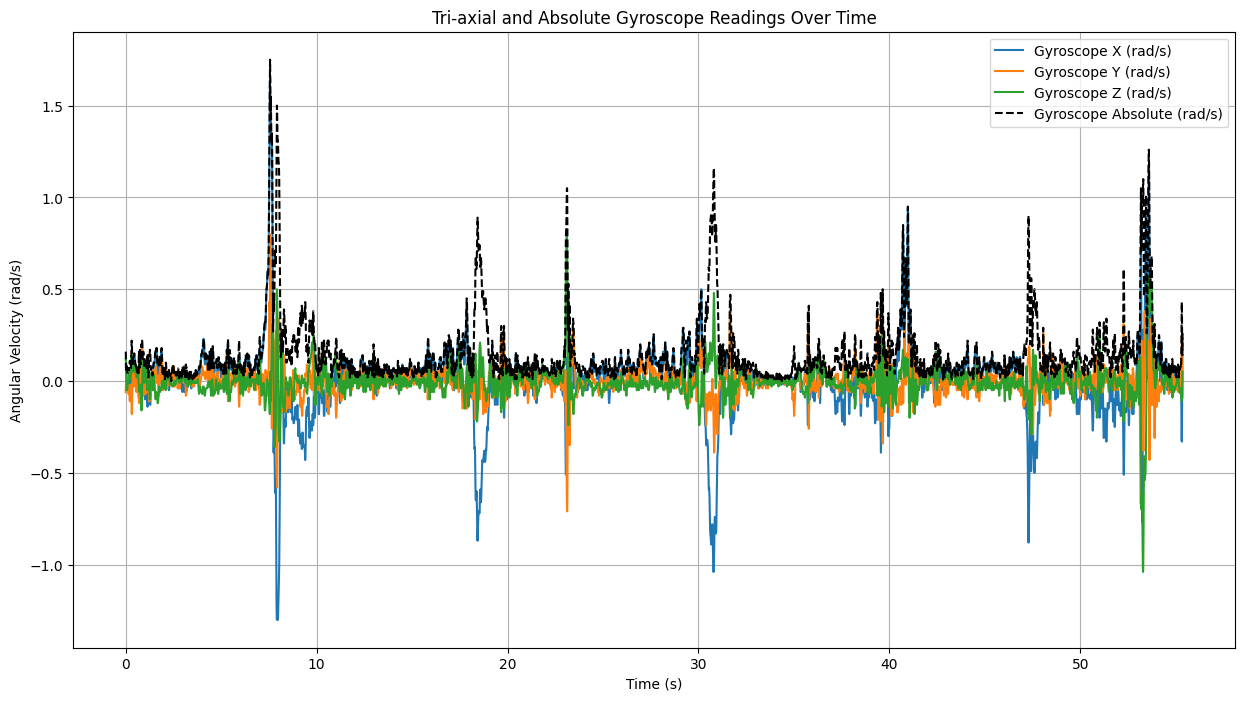

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.lineplot(x='time_s', y='gyro_x', data=df, label='Gyroscope X (rad/s)')
sns.lineplot(x='time_s', y='gyro_y', data=df, label='Gyroscope Y (rad/s)')
sns.lineplot(x='time_s', y='gyro_z', data=df, label='Gyroscope Z (rad/s)')
sns.lineplot(x='time_s', y='gyro_abs', data=df, label='Gyroscope Absolute (rad/s)', linestyle='--', color='black')

plt.title('Tri-axial and Absolute Gyroscope Readings Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity (rad/s)')
plt.grid(True)
plt.legend()
plt.show()

### 3. Identifying the Fall Event and Labeling Data

To build our classification model, we need to label the data as either 'SAFE' (0) or 'UNSAFE/FALL' (1). The transition from SAFE to UNSAFE occurs when the rotational static friction fails and the payload slides off. We can identify this critical moment, or 'fall_time', by detecting a significant and sustained increase in the `gyro_abs` (absolute angular velocity). This point will serve as our 'physical threshold' for the friction failure.

We will define a threshold for `gyro_abs` and mark the first time this threshold is exceeded as the `fall_time`. Data points before this time will be considered SAFE, and those after will be considered UNSAFE/FALL.

Detected 7 potential fall events.
Fall 1 detected at time_s = 7.56 seconds, with absolute angular velocity = 1.75 rad/s.
Fall 2 detected at time_s = 18.43 seconds, with absolute angular velocity = 0.89 rad/s.
Fall 3 detected at time_s = 23.11 seconds, with absolute angular velocity = 1.05 rad/s.
Fall 4 detected at time_s = 30.80 seconds, with absolute angular velocity = 1.16 rad/s.
Fall 5 detected at time_s = 40.97 seconds, with absolute angular velocity = 0.95 rad/s.
Fall 6 detected at time_s = 47.29 seconds, with absolute angular velocity = 0.90 rad/s.
Fall 7 detected at time_s = 53.59 seconds, with absolute angular velocity = 1.26 rad/s.

Overall experimental threshold for rotational static friction failure (max gyro_abs during fall events): 1.75 rad/s.

First 5 rows with labels:


,time_s,gyro_x,gyro_y,gyro_z,gyro_abs,label
0,0.00,0.09,-0.06,0.12,0.16,0
1,0.01,0.06,-0.02,0.10,0.12,0
2,0.02,0.04,0.03,0.06,0.08,0
3,0.03,0.02,0.06,0.02,0.06,0
4,0.04,0.01,0.08,-0.02,0.08,0



Last 5 rows with labels:


,time_s,gyro_x,gyro_y,gyro_z,gyro_abs,label
5539,55.32,-0.33,0.25,-0.11,0.43,0
5540,55.33,-0.25,0.23,-0.09,0.35,0
5541,55.34,-0.05,0.11,-0.07,0.14,0
5542,55.35,0.14,0.00,-0.02,0.14,0
5543,55.36,0.23,-0.09,0.05,0.26,0



Value counts for labels:


,count
label,
0,4837
1,707


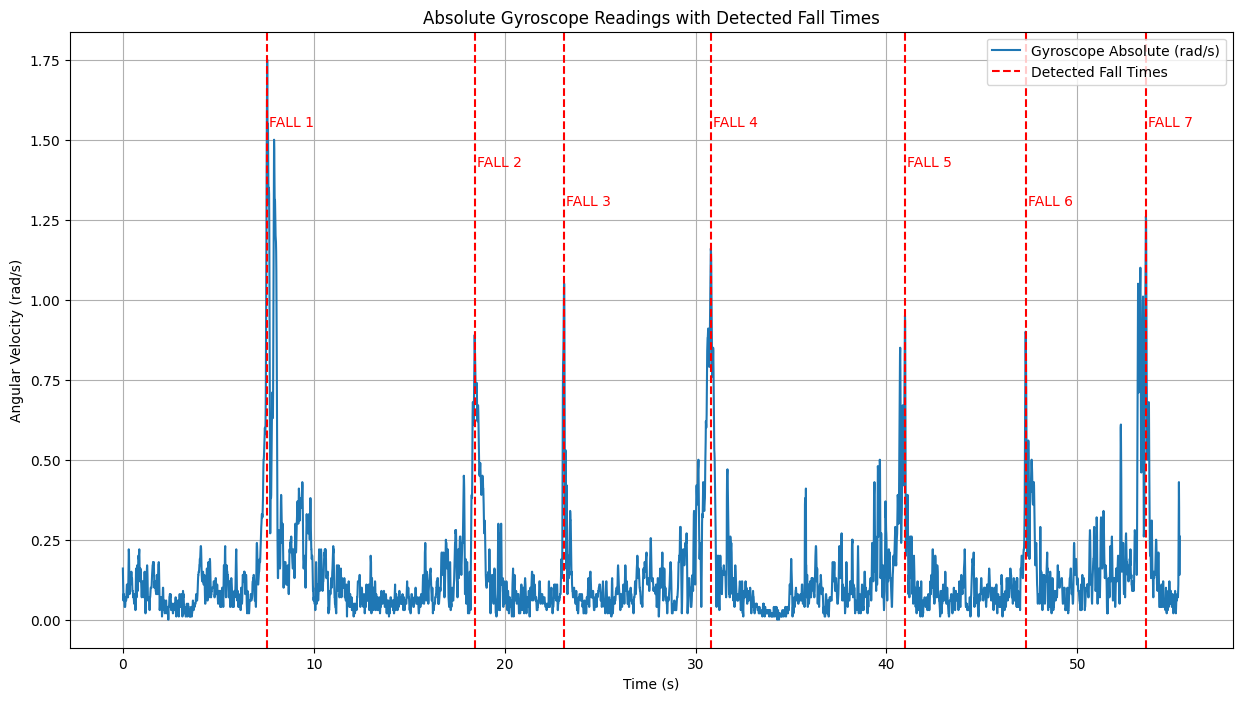

In [39]:
import scipy.signal
import matplotlib.pyplot as plt
import seaborn as sns

# Find peaks in gyro_abs. We need to choose appropriate parameters for height and distance.
# 'height' parameter: minimum height of a peak. Let's try 0.7 rad/s based on visual inspection of the plot.
# 'distance' parameter: minimum horizontal distance (in samples) between neighboring peaks.
# A distance of 100 samples corresponds to 1 second (given 0.01s sampling rate), ensuring distinct fall events are captured.
peak_indices, properties = scipy.signal.find_peaks(df['gyro_abs'], height=0.7, distance=100)

# Convert peak indices to time values
fall_times = df['time_s'].iloc[peak_indices].tolist()
fall_gyro_abs_values = df['gyro_abs'].iloc[peak_indices].tolist()

print(f"Detected {len(fall_times)} potential fall events.")
for i, (f_time, f_gyro_abs) in enumerate(zip(fall_times, fall_gyro_abs_values)):
    print(f"Fall {i+1} detected at time_s = {f_time:.2f} seconds, with absolute angular velocity = {f_gyro_abs:.2f} rad/s.")

# The overall fall_threshold_gyro_abs for the mu_s calculation will be the maximum of these detected fall gyro_abs values.
fall_threshold_gyro_abs = max(fall_gyro_abs_values) if fall_gyro_abs_values else 0.0

print(f"\nOverall experimental threshold for rotational static friction failure (max gyro_abs during fall events): {fall_threshold_gyro_abs:.2f} rad/s.")

# Create a 'label' column: 0 for SAFE, 1 for UNSAFE/FALL
df['label'] = 0 # Initialize all as SAFE

# Label a period of 1 second AFTER each detected fall time as 'UNSAFE' (1)
# This aligns with the 1-second window size used in feature engineering.
if fall_times:
    # Assuming uniform sampling rate; calculate from first few samples
    sampling_rate = 1 / (df['time_s'].iloc[1] - df['time_s'].iloc[0]) if len(df) > 1 else 100 # Default to 100Hz if df is too short
    label_duration_samples = int(1 * sampling_rate) # Label for 1 second after the fall

    for f_time in fall_times:
        # Find the starting index for labeling
        start_index_candidates = df[df['time_s'] >= f_time].index
        if not start_index_candidates.empty:
            start_index = start_index_candidates[0]
            # Define the end index, ensuring it doesn't exceed DataFrame bounds
            end_index = min(start_index + label_duration_samples, len(df) - 1) # -1 because .loc is inclusive
            # Label the slice from start_index to end_index (inclusive)
            df.loc[start_index:end_index, 'label'] = 1

print("\nFirst 5 rows with labels:")
display(df.head())
print("\nLast 5 rows with labels:")
display(df.tail())
print("\nValue counts for labels:")
display(df['label'].value_counts())

# Visualize the data with the detected fall times
plt.figure(figsize=(15, 8))
sns.lineplot(x='time_s', y='gyro_abs', data=df, label='Gyroscope Absolute (rad/s)')

if fall_times:
    for i, f_time in enumerate(fall_times):
        # Plot vertical line for each detected fall without individual labels for the legend
        plt.axvline(x=f_time, color='r', linestyle='--')
        # Add text for each fall, adjusting position to avoid overlap
        text_y_pos = df['gyro_abs'].max() * 0.9 - (i % 3) * df['gyro_abs'].max() * 0.07 # Stack text if many falls
        plt.text(f_time + 0.1, text_y_pos, f'FALL {i+1}', color='red', verticalalignment='top', horizontalalignment='left', fontsize=10)

# Create custom legend entries
legend_handles = []
legend_labels = []

# Add the line plot's legend entry
# Using a generic color for the line plot if seaborn doesn't assign a specific one
legend_handles.append(plt.Line2D([0], [0], color=sns.color_palette()[0], label='Gyroscope Absolute (rad/s)'))
legend_labels.append('Gyroscope Absolute (rad/s)')

# Add the custom handle for the fall lines
if fall_times:
    legend_handles.append(plt.Line2D([0], [0], color='r', linestyle='--', label='Detected Fall Times'))
    legend_labels.append('Detected Fall Times')

plt.title('Absolute Gyroscope Readings with Detected Fall Times')
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity (rad/s)')
plt.grid(True)
plt.legend(legend_handles, legend_labels, loc='upper right')
plt.show()

### Re-running Feature Engineering and Model Training with Multiple Fall Detections

Now that we have detected multiple fall events and updated the data labeling, we need to re-run the feature engineering, model training, and evaluation steps to reflect these changes. This will ensure our model is trained on the full spectrum of identified fall scenarios.

In [41]:
# Re-run feature engineering
# Define window parameters (e.g., 1 second window with 50% overlap)
# Since the sampling rate is 100Hz (0.01s per sample), a 1-second window is 100 samples.
window_size = 100 # 100 samples = 1 second
step_size = 50    # 50 samples = 0.5 second (50% overlap)

X, y = create_features(df, window_size, step_size)

print(f"Generated {len(X)} windows with {len(X.columns)} features each.")
print("Features (X) head:")
display(X.head())
print("Labels (y) value counts:")
display(y.value_counts())

# Re-run data splitting and scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data into training and testing sets
# Check if there's enough data for both classes in both splits
if y.nunique() > 1 and y.value_counts().min() > 1:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    print("Data split into training and testing sets with stratification.")
else:
    # If not enough samples for stratification (e.g., only one '1' class sample), proceed without it or adjust.
    print("Warning: Not enough samples for stratified split. Attempting to ensure both classes are present in train/test if possible, or using simple split.")
    # More robust handling for very imbalanced cases with multiple '1's
    if 1 in y.values and y.value_counts()[1] < 2: # If only one '1' label or zero '1' labels
        # If there's only one '1' label, place it in train set for model to learn it.
        # This approach might still lead to a test set with no '1's if test_size is large.
        idx_1 = y[y == 1].index[0]
        X_train_temp = X.drop(index=idx_1)
        y_train_temp = y.drop(index=idx_1)
        X_test = X.loc[[idx_1]] # Put the single '1' into X_test initially as a special case
        y_test = y.loc[[idx_1]]

        # Split the remaining '0's for train and test
        X_train_0, X_test_0, y_train_0, y_test_0 = train_test_split(X_train_temp[y_train_temp == 0], y_train_temp[y_train_temp == 0], test_size=0.3, random_state=42)

        # Combine, making sure the single '1' is in the training set
        X_train = pd.concat([X_train_0, X.loc[[idx_1]]])
        y_train = pd.concat([y_train_0, y.loc[[idx_1]]])
        X_test = X_test_0 # Test set has only '0's now
        y_test = y_test_0
    elif y.nunique() == 1: # If only one class exists
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    else: # Multiple '1's, but not enough for stratified split into both train/test portions
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
        print("Using stratified split, but beware of small class representation in test set.")


print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train value counts:\n{y_train.value_counts()}")
print(f"y_test value counts:\n{y_test.value_counts()}")

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled.")

Generated 109 windows with 20 features each.
Features (X) head:


,mean_gyro_x,std_gyro_x,min_gyro_x,max_gyro_x,iqr_gyro_x,mean_gyro_y,std_gyro_y,min_gyro_y,max_gyro_y,iqr_gyro_y,mean_gyro_z,std_gyro_z,min_gyro_z,max_gyro_z,iqr_gyro_z,mean_gyro_abs,std_gyro_abs,min_gyro_abs,max_gyro_abs,iqr_gyro_abs
0,0.0331,0.050466,-0.09,0.13,0.0800,-0.0083,0.075746,-0.18,0.21,0.10,0.0237,0.065129,-0.16,0.14,0.0900,0.1096,0.046055,0.03,0.22,0.07
1,0.0092,0.067654,-0.14,0.12,0.1125,-0.0046,0.068452,-0.12,0.21,0.09,0.0032,0.062456,-0.16,0.11,0.0900,0.1059,0.044497,0.02,0.22,0.07
2,0.0285,0.080634,-0.14,0.17,0.1100,0.0007,0.050757,-0.11,0.12,0.08,-0.0251,0.052561,-0.12,0.11,0.0600,0.1068,0.041167,0.02,0.18,0.07
3,0.0454,0.057462,-0.05,0.17,0.0825,0.0148,0.038911,-0.08,0.12,0.05,-0.0271,0.040058,-0.12,0.04,0.0525,0.0832,0.049131,0.00,0.18,0.08
4,0.0049,0.031382,-0.06,0.07,0.0425,0.0114,0.029440,-0.04,0.09,0.04,0.0049,0.022451,-0.05,0.05,0.0300,0.0458,0.019755,0.00,0.10,0.03


Labels (y) value counts:


,count
0,82
1,27


Data split into training and testing sets with stratification.
X_train shape: (76, 20)
X_test shape: (33, 20)
y_train value counts:
0    57
1    19
Name: count, dtype: int64
y_test value counts:
0    25
1     8
Name: count, dtype: int64

Features scaled.


### Re-running Model Training and Evaluation

With the updated features and more balanced labels across training and testing sets, we will now retrain our TinyML model and evaluate its performance, paying close attention to its ability to detect 'UNSAFE/FALL' events.

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353 (1.38 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)


Model training complete.


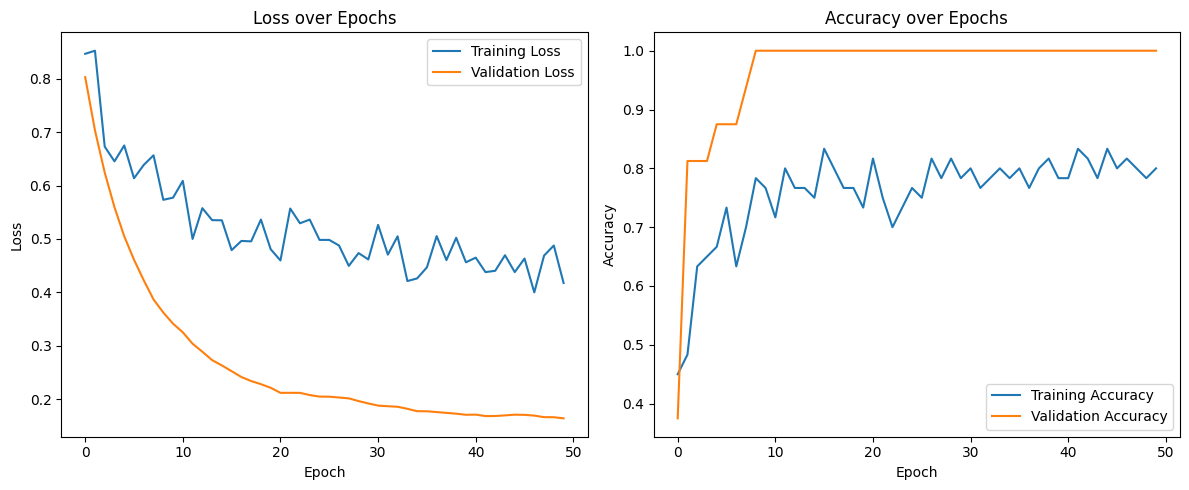

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

--- Model Evaluation on Test Set ---

Confusion Matrix:
[[24  1]
 [ 1  7]]


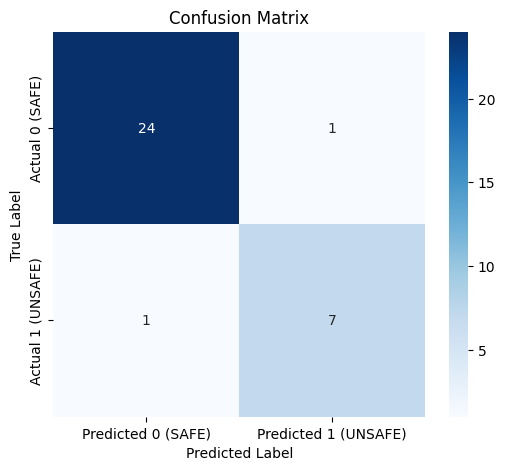


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        25
           1       0.88      0.88      0.88         8

    accuracy                           0.94        33
   macro avg       0.92      0.92      0.92        33
weighted avg       0.94      0.94      0.94        33


Test Loss: 0.2980
Test Accuracy: 0.9394

Experimental Angular Velocity at Fall (omega): 1.75 rad/s
Assumed Platform Radius (R): 0.15 m
Acceleration due to Gravity (g): 9.81 m/s^2

Experimental Coefficient of Static Friction (mu_s): 0.0468
Saved artifact at '/tmp/tmpu_ork3nw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20), dtype=tf.float32, name='keras_tensor_12')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134637222224208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134637222223632: TensorSpec(shape=(), dtype=tf.resource, na

In [42]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the TinyML model architecture (re-instantiate to clear previous state)
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),  # Input layer matches the number of features
    layers.Dense(16, activation='relu'),            # Hidden layer with ReLU activation
    layers.Dropout(0.2),                             # Dropout for regularization
    layers.Dense(1, activation='sigmoid')            # Output layer for binary classification
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train the model
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,                       # Number of epochs can be adjusted
    batch_size=8,                    # Batch size can be adjusted
    validation_split=0.2,            # Use a validation split from the training data
    verbose=0                        # Suppress verbose output during training
)

print("\nModel training complete.")

# Plot training history (loss and accuracy)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Make predictions on the test set
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int) # Convert probabilities to binary predictions (0 or 1)

print("\n--- Model Evaluation on Test Set ---")

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0 (SAFE)', 'Predicted 1 (UNSAFE)'],
            yticklabels=['Actual 0 (SAFE)', 'Actual 1 (UNSAFE)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Generate Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0)) # zero_division=0 to handle cases where a class has no predicted samples

# Evaluate model on the test set if there's any data to predict on
if len(y_test) > 0:
    loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f"\nTest Loss: {loss:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")
else:
    print("No test samples available for full evaluation.")


# Re-run static friction calculation (as fall_threshold_gyro_abs might have changed)
# Assume a radius for the payload placement on the rotating platform (e.g., in meters)
# This value needs to be known from the experimental setup.
platform_radius_m = 0.15 # Example: 15 cm radius
g = 9.81 # Acceleration due to gravity in m/s^2

# The fall_threshold_gyro_abs is the angular velocity (omega) at which the fall was detected.
omega_rad_per_s = fall_threshold_gyro_abs

# Calculate the coefficient of static friction
mu_s = (omega_rad_per_s**2 * platform_radius_m) / g

print(f"\nExperimental Angular Velocity at Fall (omega): {omega_rad_per_s:.2f} rad/s")
print(f"Assumed Platform Radius (R): {platform_radius_m} m")
print(f"Acceleration due to Gravity (g): {g} m/s^2")
print(f"\nExperimental Coefficient of Static Friction (mu_s): {mu_s:.4f}")


# Re-run TFLite conversion (as the model has been retrained)
import tensorflow as tf
import os

# Convert the Keras model to a TensorFlow Lite model
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Enable default optimizations, which include quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert the model
tflite_model = converter.convert()

# Save the TFLite model to a file
tflite_model_path = 'payload_safety_model.tflite'
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

print(f"\nTFLite model saved to: {tflite_model_path}")

# Report the TFLite model size
model_size_bytes = os.path.getsize(tflite_model_path)
model_size_kb = model_size_bytes / 1024
print(f"TFLite Model Size: {model_size_kb:.2f} KB")

print("\nTinyML pipeline complete. The model is ready for deployment on an edge device.")

This section (`4. Feature Engineering: Windowing and Feature Extraction`) and its associated code (`664a02ab`) have been superseded by the `Re-running Feature Engineering and Model Training with Multiple Fall Detections` section (cell `f70d3867`) and its code (`6c2d1d80`). The function definition for `create_features` is retained, but its initial call is commented out.

In [43]:
from scipy.stats import iqr

def create_features(df, window_size, step_size):
    features = []
    labels = []

    for i in range(0, len(df) - window_size + 1, step_size):
        window = df.iloc[i : i + window_size]

        # Ensure the window has enough data points
        if len(window) < window_size:
            continue

        # Extract features for each gyroscope axis and absolute
        mean_gyro_x = window['gyro_x'].mean()
        std_gyro_x = window['gyro_x'].std()
        min_gyro_x = window['gyro_x'].min()
        max_gyro_x = window['gyro_x'].max()
        iqr_gyro_x = iqr(window['gyro_x']) if len(window['gyro_x']) > 1 else 0.0 # Handle case of single point window for iqr

        mean_gyro_y = window['gyro_y'].mean()
        std_gyro_y = window['gyro_y'].std()
        min_gyro_y = window['gyro_y'].min()
        max_gyro_y = window['gyro_y'].max()
        iqr_gyro_y = iqr(window['gyro_y']) if len(window['gyro_y']) > 1 else 0.0

        mean_gyro_z = window['gyro_z'].mean()
        std_gyro_z = window['gyro_z'].std()
        min_gyro_z = window['gyro_z'].min()
        max_gyro_z = window['gyro_z'].max()
        iqr_gyro_z = iqr(window['gyro_z']) if len(window['gyro_z']) > 1 else 0.0

        mean_gyro_abs = window['gyro_abs'].mean()
        std_gyro_abs = window['gyro_abs'].std()
        min_gyro_abs = window['gyro_abs'].min()
        max_gyro_abs = window['gyro_abs'].max()
        iqr_gyro_abs = iqr(window['gyro_abs']) if len(window['gyro_abs']) > 1 else 0.0

        # Determine the label for the window: if any part of the window is '1' (UNSAFE), label the whole window '1'
        window_label = 1 if (window['label'] == 1).any() else 0

        features.append([
            mean_gyro_x, std_gyro_x, min_gyro_x, max_gyro_x, iqr_gyro_x,
            mean_gyro_y, std_gyro_y, min_gyro_y, max_gyro_y, iqr_gyro_y,
            mean_gyro_z, std_gyro_z, min_gyro_z, max_gyro_z, iqr_gyro_z,
            mean_gyro_abs, std_gyro_abs, min_gyro_abs, max_gyro_abs, iqr_gyro_abs
        ])
        labels.append(window_label)

    return pd.DataFrame(features, columns=[
        'mean_gyro_x', 'std_gyro_x', 'min_gyro_x', 'max_gyro_x', 'iqr_gyro_x',
        'mean_gyro_y', 'std_gyro_y', 'min_gyro_y', 'max_gyro_y', 'iqr_gyro_y',
        'mean_gyro_z', 'std_gyro_z', 'min_gyro_z', 'max_gyro_z', 'iqr_gyro_z',
        'mean_gyro_abs', 'std_gyro_abs', 'min_gyro_abs', 'max_gyro_abs', 'iqr_gyro_abs'
    ]), pd.Series(labels)

This section (`5. Model Training: Preparing Data and Building a Lightweight Classifier`) and its associated code (`0f2602d6`) have been superseded by the `Re-running Feature Engineering and Model Training with Multiple Fall Detections` section (cell `f70d3867`) and its code (`6c2d1d80`).